# Day-6

- matplotlib again, need to cover the following plots
  - line plot
  - bar plot
  - histogram
  - scatter plot
  - boxplot
  - heatmap

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub as kg
import seaborn as sns

In [29]:
df = kg.dataset_load(kg.KaggleDatasetAdapter.PANDAS, "mosapabdelghany/medical-insurance-cost-dataset", "insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [30]:
df.shape

(1338, 7)

## Line Plot

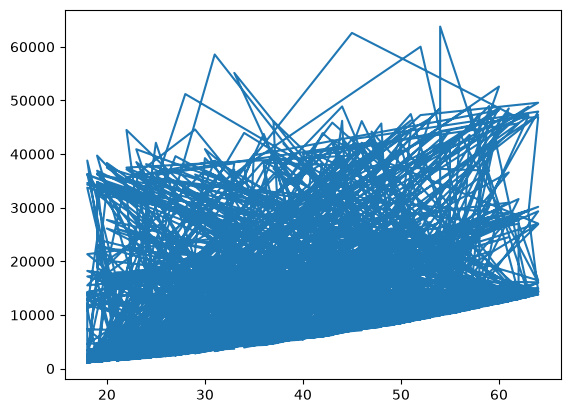

In [31]:
plt.plot(df["age"], df["charges"])

- that is a mess, should find with mean instead

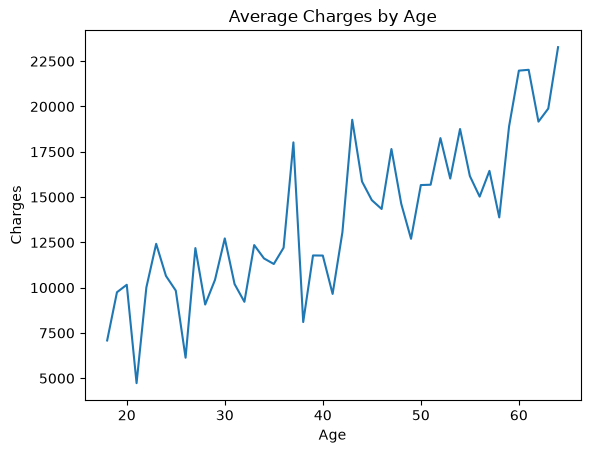

In [32]:
age_charges = df.groupby("age")["charges"].mean()

plt.plot(age_charges.index, age_charges.values)
plt.title("Average Charges by Age")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

- one line on what it tells us
  - average charges increase with age, probably because older people are more likely to have diseases

## Bar Chart

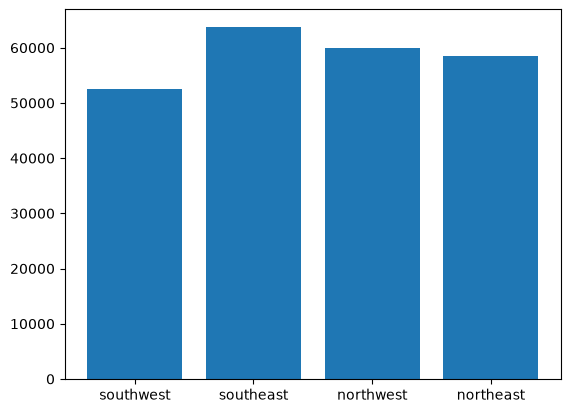

In [33]:
plt.bar(df["region"], df["charges"])
plt.show()

- the higest medical bill was from southeast
- lets try to find number of patients per region

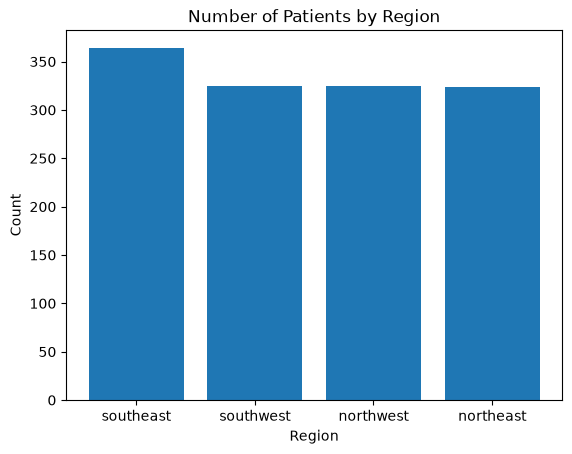

In [34]:
patients_by_region = df["region"].value_counts()
plt.bar(patients_by_region.index, patients_by_region.values)
plt.title("Number of Patients by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

- dataset has the most patients from southeast, and vaguely equal patients from the other 3 regions

## Histogram

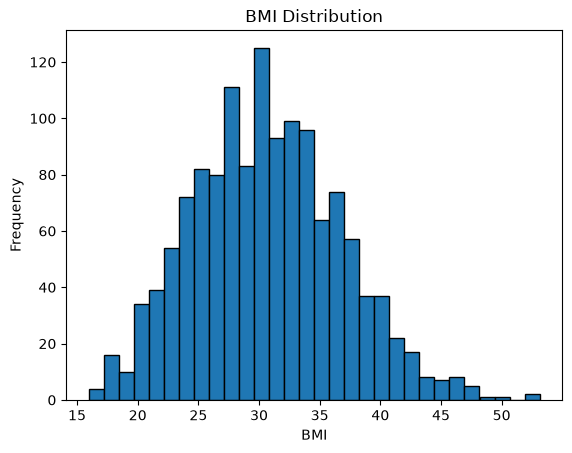

In [35]:
plt.hist(df['bmi'], bins=30, edgecolor='black')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

- just shows the distribution of bmi in the dataset, looks like a lot of people have a bmi over 30. as in very overweight

## Boxplot

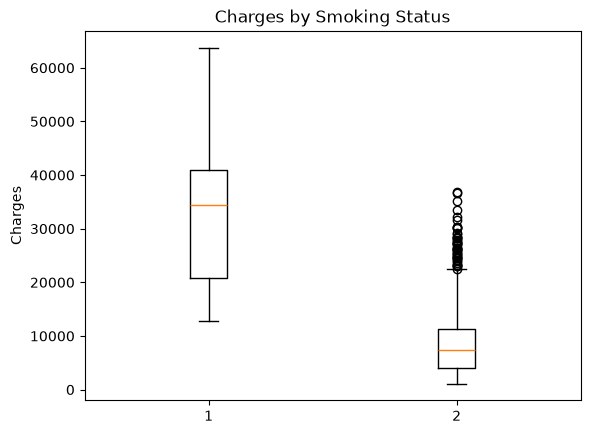

In [36]:
plt.boxplot([df[df['smoker']=='yes']['charges'], df[df['smoker']=='no']['charges']], label=['Smoker', 'Non-Smoker'])
plt.title('Charges by Smoking Status')
plt.ylabel('Charges')
plt.show()

- average health insurrance for a smoker is from 20k to 40k vaguely whereas that range is considered more of an outlier in the non-smoking group. hence, don't fricking smoke bro

## Scatter Plot

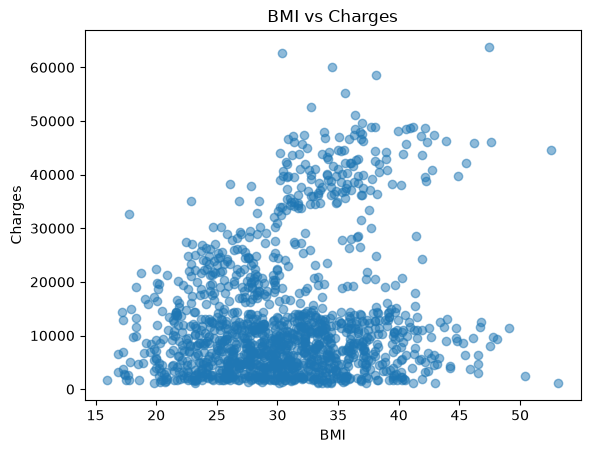

In [37]:
plt.scatter(df['bmi'], df['charges'], alpha=0.5)
plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

- bmi and charges are not super well related to eachother, they have a low correlation I think.

- ganna use ai to make a fancier scatter plot

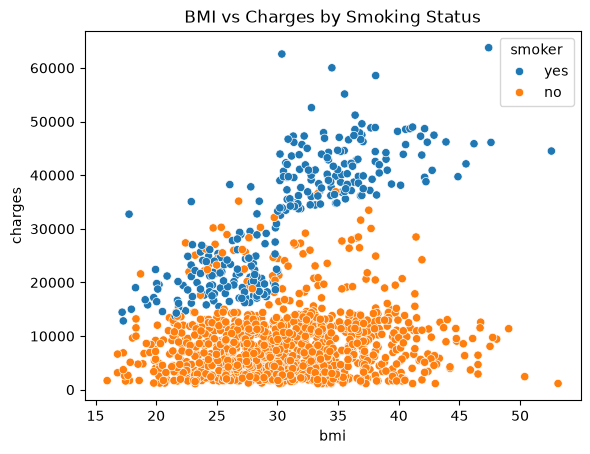

smoker     
no      bmi    0.084037
yes     bmi    0.806481
Name: charges, dtype: float64


In [38]:
# This will visually separate the subgroups
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Charges by Smoking Status")
plt.show()

# This will show you the true correlation for each separate group
print(df.groupby("smoker")[["bmi", "charges"]].corr().iloc[0::2,-1])


- well, this proves the point from the previous graph. smokers pay way more on health insurrance generally

## Heatmap

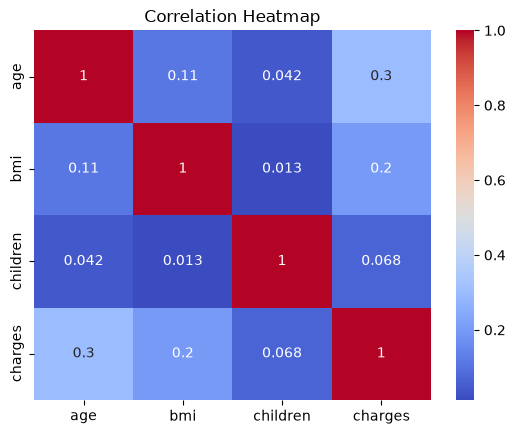

In [39]:
sns.heatmap(df[['age', 'bmi', 'children', 'charges']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

- having more kids does not mean you will have higher charges, it has absurdly low correlation at 0.068. 